<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

<string>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


<string>:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


Percentage of Fraud Tnx in datasets : 0.17%
The number of Classes before the fit Counter({0: 284315, 1: 492})
The number of Classes after the fit Counter({0: 492, 1: 492})


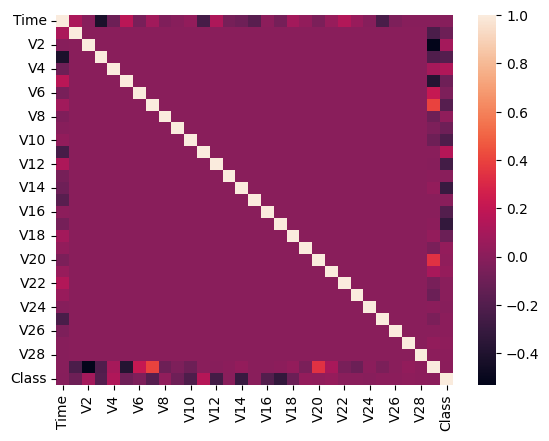

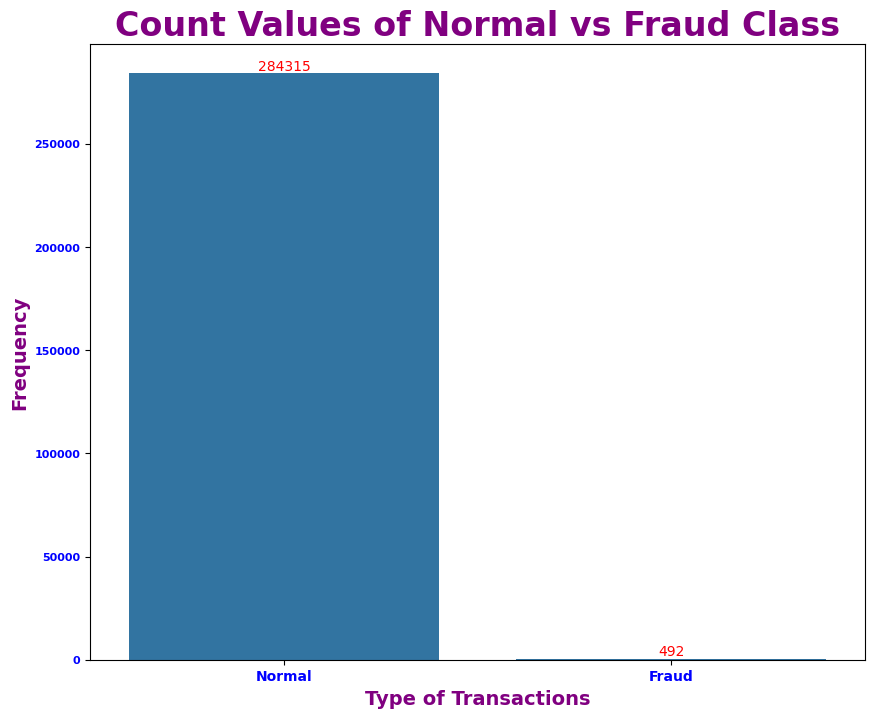

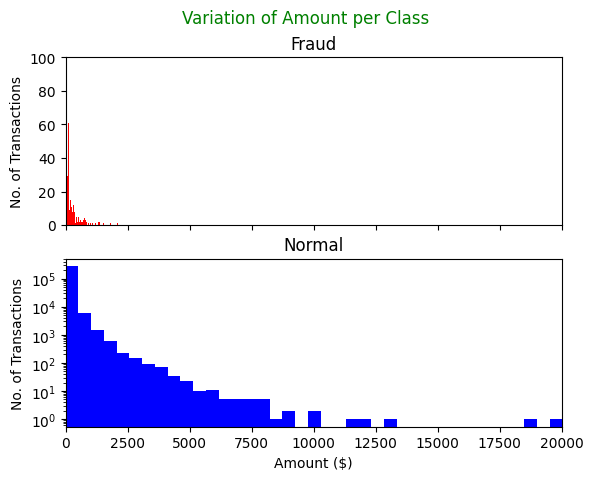

In [3]:
import import_ipynb
import dataprocessing

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [5]:
def RF_model(X,y):
    print("Spliting Datasets....")
    from sklearn.model_selection import train_test_split
    np.random.seed(42)
    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2)
    print("Successfully splitted!!!")
    
    print("Model Fitting.....")
    rf = RandomForestClassifier()
    rf.fit(X_train, y_train)
    print("Successfully model fitted!!!")

    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    print("------------Training Prediction--------------")
    y_preds = rf.predict(X_train)
    print(f"Classfifcation Report:\n\n{classification_report(y_train, y_preds)}\n\n")

    cf_matrix = confusion_matrix(y_train, y_preds)

    fig, ax = plt.subplots(figsize=(6,4))
    sns.heatmap(cf_matrix, annot=True, cmap='coolwarm', fmt='g')
    fig.suptitle(t="Confusion Matrix of Training Datasets",
                 color="orange",
                 fontsize=16);
    ax.set(xlabel="Predicted Label",
           ylabel="Actual Label");

    print(f"Accuracy Score:\n\n{accuracy_score(y_train, y_preds)*100:2f}%\n")

    print("------------Test Prediction--------------")

    y_preds = rf.predict(X_test)
    print(f"Classfifcation Report:\n\n{classification_report(y_test, y_preds)}\n\n")

    cf_matrix = confusion_matrix(y_test, y_preds)

    fig, ax = plt.subplots(figsize=(6,4))
    sns.heatmap(cf_matrix, annot=True, cmap='coolwarm', fmt='g')
    fig.suptitle(t="Confusion Matrix of Testing Datasets",
                 color="orange",
                 fontsize=16);
    ax.set(xlabel="Predicted Label",
           ylabel="Actual Label");

    print(f"Accuracy Score:\n\n{accuracy_score(y_test, y_preds)*100:2f}%\n")
    return rf

In [6]:
#RF_model(dataprocessing.X, dataprocessing.y)

In [7]:
#RF_model(dataprocessing.X_scaled, dataprocessing.y_scaled)

In [8]:
#RF_model(dataprocessing.X_undersampled, dataprocessing.y_undersampled)

In [9]:
#RF_model(dataprocessing.X_oversampled, dataprocessing.y_oversampled)

Spliting Datasets....
Successfully splitted!!!
Model Fitting.....
Successfully model fitted!!!
------------Training Prediction--------------
Classfifcation Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227565
           1       1.00      1.00      1.00    227339

    accuracy                           1.00    454904
   macro avg       1.00      1.00      1.00    454904
weighted avg       1.00      1.00      1.00    454904



Accuracy Score:

100.000000%

------------Test Prediction--------------
Classfifcation Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



Accuracy Score:

99.990328%



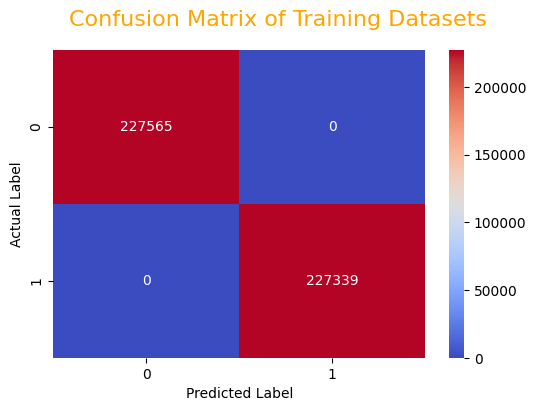

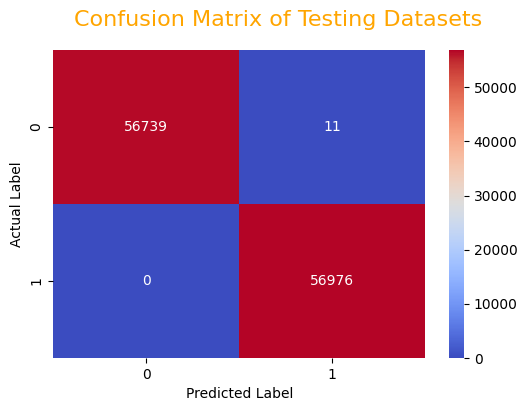

In [10]:
rforest=RF_model(dataprocessing.X_smote, dataprocessing.y_smote)

In [11]:
import os
import joblib
if not os.path.exists('ML_MODEL'):
    os.makedirs('ML_MODEL')

model_path = 'ML_MODEL/random_forest.pkl'
joblib.dump(rforest, model_path)
print(f'Model saved at {model_path}')

Model saved at ML_MODEL/random_forest.pkl


In [12]:
if not os.path.exists('ML_MODEL'):
    os.makedirs('ML_MODEL')

model_path = 'ML_MODEL/random_forestt.joblib'
joblib.dump(rforest, model_path)
print(f'Model saved at {model_path}')

Model saved at ML_MODEL/random_forestt.joblib


In [13]:
features = [0,	-1.359807134,	-0.072781173,	2.536346738,	1.378155224,	-0.33832077,	0.462387778,	0.239598554,	0.098697901,	0.36378697,	0.090794172,	-0.551599533,	-0.617800856,	-0.991389847,	-0.311169354,	1.468176972,	-0.470400525,	0.207971242,	0.02579058,	0.40399296,	0.251412098,	-0.018306778,	0.277837576,	-0.11047391,	0.066928075,	0.128539358,	-0.189114844,	0.133558377,	-0.021053053,	149.62]

# Make a prediction (assuming the model outputs 0 or 1 for fraud detection)
prediction = rforest.predict([features])[0]

# Output the prediction (1 for fraud, 0 for not fraud)
print(prediction)

0


c:\Users\Nandika\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [14]:
features = [406,	-2.312226542,	1.951992011,	-1.609850732,	3.997905588,	-0.522187865,	-1.426545319,	-2.537387306,	1.391657248,	-2.770089277,	-2.772272145,	3.202033207,	-2.899907388,	-0.595221881,	-4.289253782,	0.38972412,	-1.14074718,	-2.830055675,	-0.016822468,	0.416955705,	0.126910559,	0.517232371,	-0.035049369,	-0.465211076,	0.320198199,	0.044519167,	0.177839798,	0.261145003,	-0.143275875,	0]

# Make a prediction (assuming the model outputs 0 or 1 for fraud detection)
prediction = rforest.predict([features])[0]

# Output the prediction (1 for fraud, 0 for not fraud)
print(prediction)

1


c:\Users\Nandika\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [15]:
features = [0,-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134,	-1.359807134]

# Make a prediction (assuming the model outputs 0 or 1 for fraud detection)
prediction = rforest.predict([features])[0]

# Output the prediction (1 for fraud, 0 for not fraud)
print(prediction)

0


c:\Users\Nandika\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
